# 🎓 Probabilistic Graphical Models — Programming Exercises
### *Bayesian Networks · Markov Networks · Sum-Product Algorithm*
---
**Course:** AI – Knowledge Acquisition and Knowledge Representation  
**Topics covered:**
1. Encoding world-knowledge as a Bayesian Network  
2. Prior & posterior inference — *how evidence changes uncertainty*  
3. Conditional independence and **d-separation**  
4. Markov Random Fields (undirected models)  
5. Factor Graphs and the **Sum-Product Algorithm**  

> 💡 **How to use this notebook:**  
> Read the explanations carefully. Fill in every cell that contains `# YOUR CODE HERE` or `???`.  
> Run the assertion cells to check your work.


## Install requirements
In the terminal do: (If on lightning.ai the terminal is found through view->Terminal)
```bash
uv pip install matplotlib networkx
```

## 🔧 Setup — run this cell first


In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import numpy as np
import itertools
import warnings
from collections import defaultdict
from typing import Dict, List, Tuple, Optional, Set
warnings.filterwarnings('ignore')

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

print("✅  All imports successful.")


✅  All imports successful.


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
#  BayesianNetwork class
#  Stores CPTs and supports exact inference via variable elimination.
# ══════════════════════════════════════════════════════════════════════════════

class BayesianNetwork:
    """
    A Bayesian Network (DAG + CPTs).

    Parameters
    ----------
    nodes   : list of str   — all variable names
    parents : dict          — {child: [parent, ...]}  (empty list for roots)
    cpts    : dict          — {node: np.ndarray}
              For a node with parents p1, p2 the array has shape
              (|dom p1|, |dom p2|, |dom node|), last axis = child variable.
    domains : dict          — {node: list}  default {node: [False, True]}
    """

    def __init__(self,
                 nodes: List[str],
                 parents: Dict[str, List[str]],
                 cpts: Dict[str, np.ndarray],
                 domains: Optional[Dict[str, list]] = None):
        self.nodes   = nodes
        self.parents = parents
        self.cpts    = cpts
        self.domains = domains or {n: [False, True] for n in nodes}

    # ── helpers ───────────────────────────────────────────────────────────────
    def _parent_idx(self, node: str, assignment: dict) -> tuple:
        """Return the index tuple for the parents of `node` in the CPT."""
        return tuple(
            self.domains[p].index(assignment[p])
            for p in self.parents[node]
        )

    def cpt_lookup(self, node: str, assignment: dict) -> float:
        """P(node = assignment[node] | parents(node) = assignment[parents])"""
        dom   = self.domains[node]
        val   = assignment[node]
        pidx  = self._parent_idx(node, assignment)
        cidx  = dom.index(val)
        if not self.parents[node]:
            return float(self.cpts[node][cidx])
        return float(self.cpts[node][pidx + (cidx,)])

    # ── joint probability ─────────────────────────────────────────────────────
    def joint_probability(self, assignment: dict) -> float:
        """
        P(X1=x1, ..., Xn=xn) via the BN chain rule:
            P = ∏_i  P(Xi | Parents(Xi))
        """
        p = 1.0
        for node in self.nodes:
            p *= self.cpt_lookup(node, assignment)
        return p

    # ── exact inference (enumerate all worlds) ────────────────────────────────
    def query(self, query_var: str,
              evidence: dict) -> Dict:
        """
        Compute P(query_var | evidence) by summing over all hidden variables.

        Returns a normalised distribution {value: probability}.
        """
        hidden = [n for n in self.nodes
                  if n != query_var and n not in evidence]
        result = {v: 0.0 for v in self.domains[query_var]}

        # iterate over all combinations of hidden-variable values
        for combo in itertools.product(*[self.domains[h] for h in hidden]):
            assignment = dict(zip(hidden, combo))
            assignment.update(evidence)
            for val in self.domains[query_var]:
                assignment[query_var] = val
                result[val] += self.joint_probability(assignment)

        # normalise
        total = sum(result.values())
        return {v: p / total for v, p in result.items()}

    # ── convenience: marginal ─────────────────────────────────────────────────
    def marginal(self, var: str) -> Dict:
        """P(var) — no evidence."""
        return self.query(var, evidence={})

    # ── visualisation ─────────────────────────────────────────────────────────
    def draw(self, title: str = "Bayesian Network",
             pos: dict = None, figsize=(8, 5)):
        G = nx.DiGraph()
        G.add_nodes_from(self.nodes)
        for child, pars in self.parents.items():
            for p in pars:
                G.add_edge(p, child)
        if pos is None:
            pos = nx.spring_layout(G, seed=42)
        fig, ax = plt.subplots(figsize=figsize)
        nx.draw_networkx(G, pos=pos, ax=ax,
                         node_size=2000, node_color='#AED6F1',
                         font_size=10, arrows=True,
                         arrowsize=20, edge_color='#2C3E50',
                         connectionstyle='arc3,rad=0.05')
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.axis('off')
        plt.tight_layout()
        plt.show()

print("✅  BayesianNetwork class loaded.")


✅  BayesianNetwork class loaded.


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
#  d-Separation checker  (Bayes-Ball algorithm, Koller & Friedman)
# ══════════════════════════════════════════════════════════════════════════════

def d_separated(bn: BayesianNetwork,
                X: Set[str],
                Y: Set[str],
                Z: Set[str]) -> bool:
    """
    Return True if X and Y are d-separated given evidence Z.

    Uses the Bayes-Ball algorithm:
      going_up=True  → travelling in the diagnostic direction (child → parent)
      going_up=False → travelling in the causal direction   (parent → child)

    Three structural patterns on a path through node z:
      Chain  X→z→Y   : blocked when z IS observed (z ∈ Z)
      Fork   X←z→Y   : blocked when z IS observed (z ∈ Z)
      Collider X→z←Y : blocked when z (or any descendant) is NOT observed
    """
    children = defaultdict(set)
    for child, pars in bn.parents.items():
        for p in pars: children[p].add(child)

    # L = Z ∪ ancestors(Z) — the set that activates colliders
    L = set(Z)
    q = list(Z)
    while q:
        n = q.pop()
        for p in bn.parents.get(n, []):
            if p not in L: L.add(p); q.append(p)

    # BFS over (node, direction) pairs
    via     = set((x, True) for x in X)   # start going UP from X
    visited = set()

    while via:
        node, going_up = via.pop()
        if (node, going_up) in visited: continue
        visited.add((node, going_up))

        if node in Y: return False   # active path found → NOT d-separated

        if going_up and node not in Z:
            # Unobserved in diagnostic direction: chain/fork active
            for p in bn.parents.get(node, []):
                if (p, True)  not in visited: via.add((p, True))
            for c in children[node]:
                if (c, False) not in visited: via.add((c, False))

        if not going_up:
            if node not in Z:
                # Not observed: continue downstream (chain active)
                for c in children[node]:
                    if (c, False) not in visited: via.add((c, False))
            if node in L:
                # Collider activated (node or a descendant is observed)
                for p in bn.parents.get(node, []):
                    if (p, True) not in visited: via.add((p, True))

    return True   # no active path → d-separated


def check_independence(bn, X, Y, Z=None, verbose=True):
    """Pretty-print a d-separation query and return the boolean result."""
    Z = Z or set()
    sep    = d_separated(bn, set(X), set(Y), set(Z))
    result = ("d-separated  \u27f9  CONDITIONALLY INDEPENDENT"
              if sep else
              "NOT d-separated  \u27f9  CONDITIONALLY DEPENDENT")
    if verbose:
        zstr = f" given {{{', '.join(Z)}}}" if Z else " (unconditionally)"
        print(f"  {{{', '.join(X)}}} \u22a5 {{{', '.join(Y)}}}{zstr}")
        print(f"  \u2192 {result}")
    return sep

print("\u2705  d-Separation functions loaded.")


✅  d-Separation functions loaded.


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  MarkovNetwork  (undirected graphical model / MRF)
#  Clique potentials are stored as dicts: {(val1, val2, ...): float}
# ══════════════════════════════════════════════════════════════════════════════

class MarkovNetwork:
    """
    A Markov Random Field.

    Parameters
    ----------
    nodes      : list of str
    edges      : list of (str, str)   — undirected edge list
    cliques    : list of list of str  — maximal cliques (node groups)
    potentials : list of dict         — one dict per clique;
                 keys are value tuples, values are non-negative floats
    domains    : dict  {node: list}
    """

    def __init__(self,
                 nodes      : List[str],
                 edges      : List[Tuple[str, str]],
                 cliques    : List[List[str]],
                 potentials : List[Dict],
                 domains    : Optional[Dict[str, list]] = None):
        self.nodes      = nodes
        self.edges      = edges
        self.cliques    = cliques
        self.potentials = potentials
        self.domains    = domains or {n: [False, True] for n in nodes}

    def _all_worlds(self):
        """Generator over all complete variable assignments."""
        for combo in itertools.product(*[self.domains[n] for n in self.nodes]):
            yield dict(zip(self.nodes, combo))

    def unnormalised_score(self, assignment: dict) -> float:
        """Product of all clique potentials for a given world."""
        score = 1.0
        for clique, phi in zip(self.cliques, self.potentials):
            key    = tuple(assignment[v] for v in clique)
            score *= phi.get(key, 0.0)
        return score

    def partition_function(self) -> float:
        """Z = Σ_x  ∏_k φ_k(x_k)"""
        return sum(self.unnormalised_score(w) for w in self._all_worlds())

    def joint_probability(self, assignment: dict) -> float:
        """P(x) = (1/Z) ∏_k φ_k(x_k)"""
        return self.unnormalised_score(assignment) / self.partition_function()

    def marginal(self, var: str) -> Dict:
        """P(var) by summing over all other variables."""
        Z    = self.partition_function()
        dist = {v: 0.0 for v in self.domains[var]}
        for world in self._all_worlds():
            dist[world[var]] += self.unnormalised_score(world)
        return {v: p / Z for v, p in dist.items()}

    def query(self, query_var: str, evidence: dict) -> Dict:
        """P(query_var | evidence) via enumeration."""
        dist = {v: 0.0 for v in self.domains[query_var]}
        for world in self._all_worlds():
            if any(world[e] != val for e, val in evidence.items()):
                continue
            for val in self.domains[query_var]:
                world[query_var] = val
                dist[val] += self.unnormalised_score(world)
        total = sum(dist.values())
        return {v: p / total for v, p in dist.items()} if total > 0 else dist

    def draw(self, title="Markov Network", pos=None, figsize=(8, 5)):
        G = nx.Graph()
        G.add_nodes_from(self.nodes)
        G.add_edges_from(self.edges)
        if pos is None:
            pos = nx.spring_layout(G, seed=42)
        fig, ax = plt.subplots(figsize=figsize)
        nx.draw_networkx(G, pos=pos, ax=ax,
                         node_size=2000, node_color='#A9DFBF',
                         font_size=10, edge_color='#1E8449', width=2)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.axis('off')
        plt.tight_layout()
        plt.show()

print("\u2705  MarkovNetwork class loaded.")


✅  MarkovNetwork class loaded.


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  FactorGraph  +  Sum-Product (Belief Propagation) algorithm
#  Restricted here to tree-structured factor graphs (exact inference).
# ══════════════════════════════════════════════════════════════════════════════

class Factor:
    """
    A single factor (clique potential / CPT) in a factor graph.

    Parameters
    ----------
    name      : str
    variables : list of str  — variable names involved
    table     : dict         — {(val1, val2, ...): float}
    """
    def __init__(self, name: str, variables: List[str], table: Dict):
        self.name      = name
        self.variables = variables
        self.table     = table

    def evaluate(self, assignment: dict) -> float:
        key = tuple(assignment[v] for v in self.variables)
        return self.table.get(key, 0.0)


class SumProductSolver:
    """
    Sum-Product / Belief Propagation algorithm on a TREE factor graph.
    Computes the exact marginal distribution of every variable node.

    Algorithm overview
    ------------------
    1. Root the tree at a chosen variable node.
    2. COLLECT pass  (leaves \u2192 root): messages travel inward.
    3. DISTRIBUTE pass  (root \u2192 leaves): messages travel outward.
    4. Each variable marginal = normalised product of all incoming messages.

    Message equations
    -----------------
    Variable \u2192 Factor:
      \u03bc_{x\u2192f}(x) = \u220f_{f'\u2208ne(x)\\{f}}  \u03bc_{f'\u2192x}(x)

    Factor \u2192 Variable:
      \u03bc_{f\u2192x}(x) = \u03a3_{~x}  [ \u03c6(x_clique) \u00b7 \u220f_{x'\u2208ne(f)\\{x}} \u03bc_{x'\u2192f}(x') ]
    """

    def __init__(self,
                 variables : List[str],
                 domains   : Dict[str, list],
                 factors   : List[Factor],
                 edges     : List[Tuple[str, str]]):
        self.variables = variables
        self.domains   = domains
        self.factors   = {f.name: f for f in factors}
        self.edges = edges  # kept for draw_factor_graph
        self.var_neighbors = defaultdict(set)   # var  → set of factor names
        self.fac_neighbors = defaultdict(set)   # factor → set of var names
        for v, f in edges:
            self.var_neighbors[v].add(f)
            self.fac_neighbors[f].add(v)

    def _msg_var_to_fac(self, var: str, fac_name: str, messages: dict) -> Dict:
        """\u03bc_{var\u2192fac}(x) = \u220f_{f'\u2260fac} \u03bc_{f'\u2192var}(x)"""
        result = {v: 1.0 for v in self.domains[var]}
        for f_name in self.var_neighbors[var]:
            if f_name == fac_name:
                continue
            msg = messages.get((f_name, var), {v: 1.0 for v in self.domains[var]})
            for v in self.domains[var]:
                result[v] *= msg[v]
        return result

    def _msg_fac_to_var(self, fac_name: str, var: str, messages: dict) -> Dict:
        """\u03bc_{fac\u2192var}(x) = \u03a3_{~x} [\u03c6 \u00b7 \u220f_{x'\u2260var} \u03bc_{x'\u2192fac}(x')]"""
        fac    = self.factors[fac_name]
        others = [v for v in fac.variables if v != var]
        result = {val: 0.0 for val in self.domains[var]}
        for var_val in self.domains[var]:
            for combo in itertools.product(*[self.domains[o] for o in others]):
                assign      = dict(zip(others, combo))
                assign[var] = var_val
                prod        = fac.evaluate(assign)
                for o, o_val in zip(others, combo):
                    msg   = messages.get((o, fac_name),
                                         {v: 1.0 for v in self.domains[o]})
                    prod *= msg[o_val]
                result[var_val] += prod
        return result

    def _bfs_order(self, root: str) -> list:
        """BFS edges from root outward (root \u2192 leaves). Each entry: (src, dst, src_is_factor)."""
        from collections import deque
        visited = {root}; queue = deque(); order = []
        for f in sorted(self.var_neighbors[root]):
            if f not in visited:
                queue.append((root, f, False)); visited.add(f)
        while queue:
            src, dst, src_is_fac = queue.popleft()
            order.append((src, dst, src_is_fac))
            if src_is_fac:
                for f2 in sorted(self.var_neighbors[dst]):   # dst is variable
                    if f2 not in visited:
                        visited.add(f2); queue.append((dst, f2, False))
            else:
                for v in sorted(self.fac_neighbors[dst]):    # dst is factor
                    if v not in visited:
                        visited.add(v); queue.append((dst, v, True))
        return order

    def run(self, root: str = None, verbose: bool = False) -> Dict[str, Dict]:
        """Run Sum-Product and return {variable: {value: probability}}."""
        root = root or self.variables[0]
        messages = {}
        distribute_order = self._bfs_order(root)
        # Collect order = reverse distribute, flip each edge direction
        collect_order = [(dst, src, not is_fac)
                         for src, dst, is_fac in reversed(distribute_order)]

        for src, dst, src_is_fac in collect_order:     # leaves \u2192 root
            if src_is_fac: messages[(src,dst)] = self._msg_fac_to_var(src, dst, messages)
            else:          messages[(src,dst)] = self._msg_var_to_fac(src, dst, messages)

        for src, dst, src_is_fac in distribute_order:  # root \u2192 leaves
            if src_is_fac: messages[(src,dst)] = self._msg_fac_to_var(src, dst, messages)
            else:          messages[(src,dst)] = self._msg_var_to_fac(src, dst, messages)

        marginals = {}
        for var in self.variables:
            belief = {v: 1.0 for v in self.domains[var]}
            for f_name in self.var_neighbors[var]:
                msg = messages.get((f_name, var), {v: 1.0 for v in self.domains[var]})
                for v in self.domains[var]: belief[v] *= msg[v]
            total = sum(belief.values())
            marginals[var] = {v: p/total for v,p in belief.items()}

        if verbose:
            print("\n=== Marginals from Sum-Product ===")
            for var, dist in marginals.items():
                print(f"  P({var}) =", {k: f"{v:.4f}" for k,v in dist.items()})
        return marginals


def print_marginals(marginals: dict):
    print("\n{'variable': {value: P(value)}}")
    print("-" * 40)
    for var, dist in sorted(marginals.items()):
        line = ", ".join(f"{k}: {v:.4f}" for k,v in dist.items())
        print(f"  P({var}) = {{ {line} }}")

print("\u2705  FactorGraph / SumProduct classes loaded.")


✅  FactorGraph / SumProduct classes loaded.


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
#  Visualisation helpers
# ══════════════════════════════════════════════════════════════════════════════

def plot_distribution(dist: dict, title: str = "",
                      color: str = "#5DADE2", ax=None):
    """Bar-chart for a probability distribution dict."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    labels = [str(k) for k in dist.keys()]
    values = list(dist.values())
    bars   = ax.bar(labels, values, color=color, edgecolor='white', linewidth=1.5)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Probability")
    ax.set_title(title, fontweight='bold')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f"{val:.3f}", ha='center', va='bottom', fontsize=9)
    return ax


def compare_distributions(dists: dict, title: str = ""):
    """
    Plot multiple distributions side-by-side.
    dists = {label: {value: prob}}
    """
    n      = len(dists)
    colors = ["#5DADE2", "#58D68D", "#F0B27A", "#BB8FCE", "#F1948A"]
    fig, axes = plt.subplots(1, n, figsize=(4*n, 3.5), sharey=True)
    if n == 1:
        axes = [axes]
    for ax, (label, dist), color in zip(axes, dists.items(), colors):
        plot_distribution(dist, title=label, color=color, ax=ax)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def draw_factor_graph(solver: SumProductSolver,
                      title: str = "Factor Graph",
                      pos: dict = None):
    """Draw a factor graph: circles = variables, squares = factors."""
    G = nx.Graph()
    G.add_nodes_from(solver.variables)
    factor_names = list(solver.factors.keys())
    G.add_nodes_from(factor_names)
    for v, f in solver.edges:
        G.add_edge(v, f)
    if pos is None:
        pos = nx.spring_layout(G, seed=7)
    fig, ax = plt.subplots(figsize=(9, 5))
    nx.draw_networkx_nodes(G, pos, nodelist=solver.variables,
                           node_shape='o', node_color='#AED6F1',
                           node_size=1800, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=factor_names,
                           node_shape='s', node_color='#FAD7A0',
                           node_size=1500, ax=ax)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#566573', width=1.5)
    var_patch = mpatches.Patch(color='#AED6F1', label='Variable node (○)')
    fac_patch = mpatches.Patch(color='#FAD7A0', label='Factor node (□)')
    ax.legend(handles=[var_patch, fac_patch], loc='upper right')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

print("✅  Visualisation helpers loaded.")


✅  Visualisation helpers loaded.


---
## Part 1 — Bayesian Networks: Encoding World Knowledge

### 🌍 The Alarm Network

A classic example from Russell & Norvig. Suppose:
- A **Burglary** or an **Earthquake** can trigger a home **Alarm**.
- If the alarm goes off, **John** and **Mary** (your neighbours) might call you.

This captures **causal knowledge** about the world.  
We represent it as a **DAG** where arrows indicate direct causal influence:

```
 Burglary    Earthquake
      ↘       ↙
        Alarm
       ↙     ↘
  JohnCalls  MaryCalls
```

Each node stores a **Conditional Probability Table (CPT)**:  
`P(node | parents)` — how likely the node is, given the state of its causes.


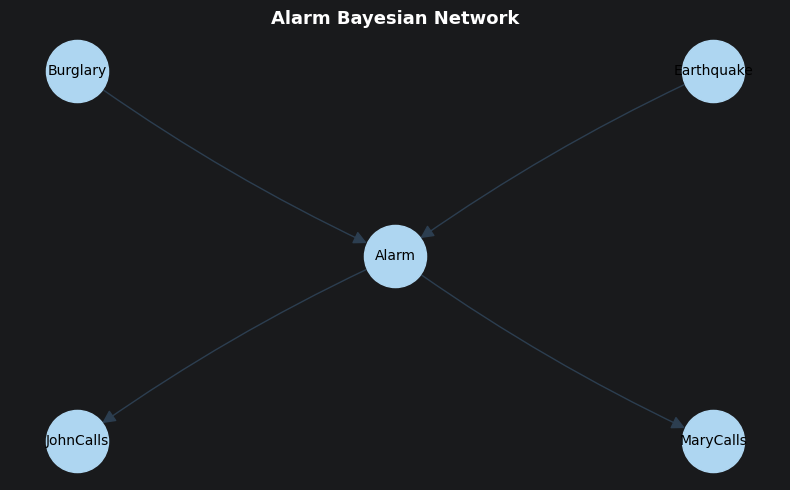

✅  Alarm BN built successfully.


In [7]:
# ── The Alarm Bayesian Network ──────────────────────────────────────────────
#
# CPT conventions:
#   • Root nodes (no parents): 1-D array [P(False), P(True)]
#   • Non-root nodes: array of shape (|par1|, |par2|, ..., |child_domain|)
#     where axis order matches the parents list, last axis = child value.
#
# For Alarm (parents: Burglary, Earthquake) the CPT has shape (2, 2, 2):
#   cpt_alarm[b][e][a] = P(Alarm=a | Burglary=b, Earthquake=e)
#
#   b=0 (False), b=1 (True)
#   e=0 (False), e=1 (True)
#   a=0 (False), a=1 (True)

cpt_burglary  = np.array([0.999, 0.001])          # P(B=False), P(B=True)
cpt_earthquake = np.array([0.998, 0.002])

#  P(Alarm | Burglary, Earthquake)
cpt_alarm = np.array([
    # Earthquake=False, Earthquake=True
    [[0.999, 0.001],   # Burglary=False  → [P(A=F|B=F,E=F), P(A=T|B=F,E=F)], ...
     [0.71,  0.29 ]],  # Burglary=False, Earthquake=True
    [[0.06,  0.94 ],   # Burglary=True,  Earthquake=False
     [0.05,  0.95 ]],  # Burglary=True,  Earthquake=True
])

cpt_john  = np.array([[0.95, 0.05],   # Alarm=False → [P(J=F|A=F), P(J=T|A=F)]
                       [0.10, 0.90]])  # Alarm=True

cpt_mary  = np.array([[0.99, 0.01],
                       [0.30, 0.70]])

# ── Assemble the BN ──────────────────────────────────────────────────────────
alarm_bn = BayesianNetwork(
    nodes   = ['Burglary', 'Earthquake', 'Alarm', 'JohnCalls', 'MaryCalls'],
    parents = {
        'Burglary'  : [],
        'Earthquake': [],
        'Alarm'     : ['Burglary', 'Earthquake'],
        'JohnCalls' : ['Alarm'],
        'MaryCalls' : ['Alarm'],
    },
    cpts = {
        'Burglary'  : cpt_burglary,
        'Earthquake': cpt_earthquake,
        'Alarm'     : cpt_alarm,
        'JohnCalls' : cpt_john,
        'MaryCalls' : cpt_mary,
    }
)

# Draw the network
alarm_pos = {
    'Burglary'  : (-1,  1),
    'Earthquake': ( 1,  1),
    'Alarm'     : ( 0,  0),
    'JohnCalls' : (-1, -1),
    'MaryCalls' : ( 1, -1),
}
alarm_bn.draw("Alarm Bayesian Network", pos=alarm_pos)
print("✅  Alarm BN built successfully.")


### 📝 Exercise 1.1 — Computing the Joint Probability

The joint probability of a complete assignment (a *possible world*) follows  
the **BN chain rule**:

$$P(B, E, A, J, M) = P(B) \cdot P(E) \cdot P(A|B,E) \cdot P(J|A) \cdot P(M|A)$$

**Task:** Compute the probability of the following specific world by hand (pen & paper),  
then verify with the `joint_probability()` method.

World: `{Burglary=True, Earthquake=False, Alarm=True, JohnCalls=True, MaryCalls=True}`


In [8]:
# ── Exercise 1.1 ──────────────────────────────────────────────────────────────
# Compute the probability of the world described above.

world = {
    'Burglary'  : True,
    'Earthquake': False,
    'Alarm'     : True,
    'JohnCalls' : True,
    'MaryCalls' : True,
}

# YOUR CODE HERE:
# Use alarm_bn.joint_probability(world) to compute the probability.
prob = ???

print(f"P(B=T, E=F, A=T, J=T, M=T) = {prob:.8f}")

# Sanity check — verify by also computing step-by-step
# P(B=T) * P(E=F) * P(A=T|B=T,E=F) * P(J=T|A=T) * P(M=T|A=T)
p_manual = (
    cpt_burglary[1]            # P(B=True)
    * cpt_earthquake[0]        # P(E=False)
    * cpt_alarm[1][0][1]       # P(A=True | B=True, E=False)
    * cpt_john[1][1]           # P(J=True | A=True)
    * cpt_mary[1][1]           # P(M=True | A=True)
)
print(f"Manual calculation:          {p_manual:.8f}")
assert abs(prob - p_manual) < 1e-10, "Values should match!"
print("✅  Passed!")


P(B=T, E=F, A=T, J=T, M=T) = 0.00059102
Manual calculation:          0.00059102
✅  Passed!


### 📝 Exercise 1.2 — Prior vs. Posterior Probability

> **Core idea:** Before we observe anything, a variable has a *prior* probability.  
> Once we observe evidence, it is updated to a *posterior* probability.  
> This is the fundamental mechanism of *probabilistic inference*.

**Task:** 
1. Compute **P(Burglary)** — the prior probability of a burglary.  
2. Compute **P(Burglary | JohnCalls=True)** — the posterior after John calls.  
3. Compute **P(Burglary | JohnCalls=True, MaryCalls=True)** — after *both* call.  
4. Observe how each piece of evidence changes the uncertainty.


Prior P(Burglary=True)                        = 0.001000
P(Burglary=True | John=True)                  = 0.016284
P(Burglary=True | John=True, Mary=True)       = 0.284172


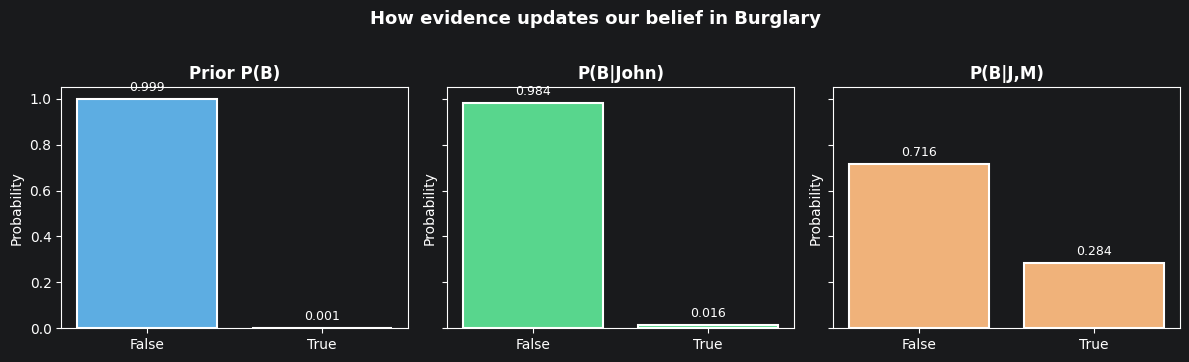

In [9]:
# ── Exercise 1.2 ──────────────────────────────────────────────────────────────

# 1. Prior P(Burglary)
prior = alarm_bn.marginal('Burglary')

# 2. Posterior P(Burglary | JohnCalls=True)
posterior_john = alarm_bn.query('Burglary', evidence={'JohnCalls': True})

# 3. Posterior P(Burglary | JohnCalls=True, MaryCalls=True)
posterior_both = ???  # YOUR CODE HERE

# Print results
print(f"Prior P(Burglary=True)                        = {prior[True]:.6f}")
print(f"P(Burglary=True | John=True)                  = {posterior_john[True]:.6f}")
print(f"P(Burglary=True | John=True, Mary=True)       = {posterior_both[True]:.6f}")

# Visualise
compare_distributions(
    {
        'Prior P(B)': prior,
        'P(B|John)' : posterior_john,
        'P(B|J,M)'  : posterior_both,
    },
    title="How evidence updates our belief in Burglary"
)


### 💬 Reflection 1.2

> **Questions to think about:**
> - Does John calling make a burglary more or less likely? Why?  
> - Why does adding Mary's call *further* increase the probability?  
> - What does this tell you about how graphical models propagate information?

Write your answers in the cell below.


In [ ]:
# ── Your reflection (write as comments) ───────────────────────────────────────

# Q1 — Does John calling make a burglary more or less likely?
# A1: 

# Q2 — Why does P(B|J,M) > P(B|J)?
# A2: 

# Q3 — What underlying mechanism propagates information through the graph?
# A3: 


### 📝 Exercise 1.3 — Explaining Away (Backward Reasoning)

> **Explaining away** is a surprising phenomenon:  
> Two independent causes of the same effect become *dependent* once the effect is observed.  
> Observing one cause "explains away" the other — reducing its probability.

**Task:**
1. Compute P(Burglary | Alarm=True)  
2. Compute P(Burglary | Alarm=True, Earthquake=True)  
3. Explain the result: why does the earthquake reduce the burglary probability?


P(Burglary=True | Alarm=True)                      = 0.3736
P(Burglary=True | Alarm=True, Earthquake=True)     = 0.0033

Explaining away: the earthquake 'explains' the alarm,
so the need for a burglary explanation decreases.


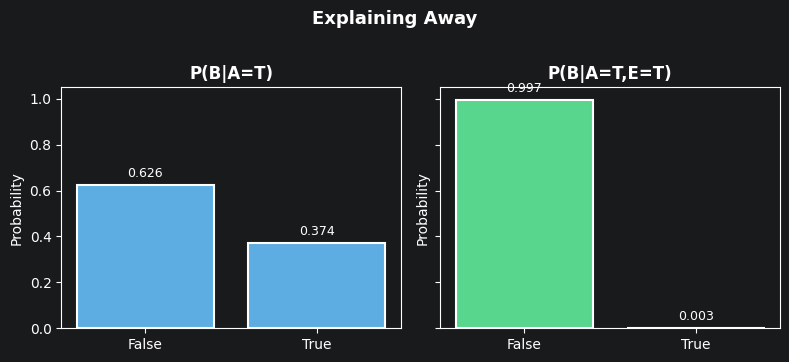

In [10]:
# ── Exercise 1.3 ──────────────────────────────────────────────────────────────

p_b_given_alarm = alarm_bn.query('Burglary', evidence={'Alarm': True})

p_b_given_alarm_eq = ???  # YOUR CODE HERE: also condition on Earthquake=True

print(f"P(Burglary=True | Alarm=True)                      = {p_b_given_alarm[True]:.4f}")
print(f"P(Burglary=True | Alarm=True, Earthquake=True)     = {p_b_given_alarm_eq[True]:.4f}")
print()
print("Explaining away: the earthquake 'explains' the alarm,")
print("so the need for a burglary explanation decreases.")

compare_distributions(
    {'P(B|A=T)': p_b_given_alarm, 'P(B|A=T,E=T)': p_b_given_alarm_eq},
    title="Explaining Away"
)


---
## Part 2 — Conditional Independence and d-Separation

### 🔍 What is d-Separation?

**d-separation** is a graph-theoretic criterion that tells us which pairs  
of variables are **conditionally independent** given some observed evidence.

It is extremely powerful: instead of computing probabilities,  
we can *read off* independencies directly from the graph structure.

#### Three canonical patterns (paths through a middle node Z):

| Pattern | Graph | Blocked by Z? | Name |
|---------|-------|---------------|------|
| Chain   | X → Z → Y | Yes (observe Z) | Causal chain |
| Fork    | X ← Z → Y | Yes (observe Z) | Common cause |
| Collider| X → Z ← Y | **No** (observe Z activates!) | Common effect |

> ⚠️ The **collider** is the surprising case:  
> X and Y are *independent* until we observe Z — then they become *dependent*.


In [11]:
# ── Exercise 2.1 — d-Separation Queries ───────────────────────────────────────
#
# Use the check_independence() function with the alarm_bn to answer these
# questions about the Alarm network.
#
# Recall the structure:
#   Burglary → Alarm ← Earthquake   (Alarm is a COLLIDER for B and E)
#   Alarm → JohnCalls
#   Alarm → MaryCalls

print("=" * 60)
print("d-Separation queries on the Alarm Network")
print("=" * 60)

# Q1: Are Burglary and Earthquake marginally independent?
print("\nQ1: Are Burglary ⊥ Earthquake (no evidence)?")
# YOUR CODE HERE — call check_independence(alarm_bn, ...)
???

# Q2: Are Burglary and Earthquake independent GIVEN Alarm=True?
print("\nQ2: Are Burglary ⊥ Earthquake | {Alarm}?")
# YOUR CODE HERE
???

# Q3: Are JohnCalls and MaryCalls independent given Alarm?
print("\nQ3: Are JohnCalls ⊥ MaryCalls | {Alarm}?")
# YOUR CODE HERE
???

# Q4: Are JohnCalls and MaryCalls independent WITHOUT observing Alarm?
print("\nQ4: Are JohnCalls ⊥ MaryCalls (no evidence)?")
# YOUR CODE HERE
???


d-Separation queries on the Alarm Network

Q1: Are Burglary ⊥ Earthquake (no evidence)?
  {Burglary} ⊥ {Earthquake} (unconditionally)
  → d-separated  ⟹  CONDITIONALLY INDEPENDENT

Q2: Are Burglary ⊥ Earthquake | {Alarm}?
  {Burglary} ⊥ {Earthquake} given {Alarm}
  → NOT d-separated  ⟹  CONDITIONALLY DEPENDENT

Q3: Are JohnCalls ⊥ MaryCalls | {Alarm}?
  {JohnCalls} ⊥ {MaryCalls} given {Alarm}
  → d-separated  ⟹  CONDITIONALLY INDEPENDENT

Q4: Are JohnCalls ⊥ MaryCalls (no evidence)?
  {JohnCalls} ⊥ {MaryCalls} (unconditionally)
  → NOT d-separated  ⟹  CONDITIONALLY DEPENDENT


False

### 📝 Exercise 2.2 — Verify d-Separation Numerically

d-separation tells us **structurally** that two variables are independent.  
Let's verify this numerically by checking if the conditional distributions  
actually satisfy the independence condition:  
$$P(X | Y, Z) = P(X | Z)$$

**Task:** Verify that **Burglary ⊥ Earthquake** (no evidence) numerically.


In [12]:
# ── Exercise 2.2 — Numerical Verification ────────────────────────────────────

# P(Burglary=True)
p_b = alarm_bn.marginal('Burglary')[True]

# P(Burglary=True | Earthquake=True)
# If they are truly independent, this should equal P(Burglary=True)
p_b_given_e = alarm_bn.query('Burglary', evidence={'Earthquake': True})[True]

# P(Burglary=True | Earthquake=False)
p_b_given_not_e = ???  # YOUR CODE HERE

print(f"P(Burglary=True)                  = {p_b:.6f}")
print(f"P(Burglary=True | Earthquake=T)   = {p_b_given_e:.6f}")
print(f"P(Burglary=True | Earthquake=F)   = {p_b_given_not_e:.6f}")

# Check independence
eps = 1e-6
are_independent = abs(p_b - p_b_given_e) < eps and abs(p_b - p_b_given_not_e) < eps
print(f"\nNumerically independent: {are_independent}")


P(Burglary=True)                  = 0.001000
P(Burglary=True | Earthquake=T)   = 0.001000
P(Burglary=True | Earthquake=F)   = 0.001000

Numerically independent: True


### 📝 Exercise 2.3 — The Collider: Explaining Away, Revisited

Now verify numerically that Burglary and Earthquake become **dependent**  
once we observe `Alarm=True` (activating the collider).

**Task:**
1. Compute P(Earthquake=True | Alarm=True)  
2. Compute P(Earthquake=True | Alarm=True, Burglary=True)  
3. Compare: does knowing about the burglary change our earthquake belief?


In [13]:
# ── Exercise 2.3 ──────────────────────────────────────────────────────────────

p_e_given_alarm = alarm_bn.query('Earthquake', evidence={'Alarm': True})[True]

p_e_given_alarm_burglary = ???  # YOUR CODE HERE: evidence = Alarm=True AND Burglary=True

print(f"P(Earthquake=T | Alarm=T)              = {p_e_given_alarm:.4f}")
print(f"P(Earthquake=T | Alarm=T, Burglary=T)  = {p_e_given_alarm_burglary:.4f}")
print()
if abs(p_e_given_alarm - p_e_given_alarm_burglary) > 1e-6:
    print("✅  They differ — Burglary and Earthquake ARE dependent given Alarm.")
    print("    This confirms that Alarm is a collider that ACTIVATES dependence.")
else:
    print("They are equal — check your code!")


P(Earthquake=T | Alarm=T)              = 0.2310
P(Earthquake=T | Alarm=T, Burglary=T)  = 0.0020

✅  They differ — Burglary and Earthquake ARE dependent given Alarm.
    This confirms that Alarm is a collider that ACTIVATES dependence.


---
## Part 3 — A Richer Example: Medical Diagnosis Network

Let's build a **medical diagnosis** network.  
This scenario is common in probabilistic AI: modelling uncertain causal chains.

```
    Smoking
       |
       ↓
   LungCancer  ← Asbestos
       |
       ↓
   XRayResult      Dyspnea (shortness of breath)
                      ↑
               LungCancer  Bronchitis
                              ↑
                           Smoking
```
Full structure:
```
  Smoking → LungCancer
  Smoking → Bronchitis
  Asbestos → LungCancer
  LungCancer → XRayResult
  LungCancer → Dyspnea
  Bronchitis → Dyspnea
```


In [ ]:
# ── Exercise 3.1 — Build the Medical Diagnosis BN ────────────────────────────
#
# Domains: all variables are boolean (False=absent, True=present)
#
# CPTs (from medical literature approximations):
#
#   P(Smoking=True)            = 0.25
#   P(Asbestos=True)           = 0.05
#   P(LungCancer|Smoking, Asbestos):
#       (S=F, A=F) → 0.01   (S=T, A=F) → 0.10
#       (S=F, A=T) → 0.05   (S=T, A=T) → 0.30
#   P(Bronchitis|Smoking):
#       S=F → 0.30           S=T → 0.60
#   P(XRayResult=Abnormal | LungCancer):
#       LC=F → 0.05          LC=T → 0.90
#   P(Dyspnea | LungCancer, Bronchitis):
#       (LC=F, B=F) → 0.05   (LC=T, B=F) → 0.65
#       (LC=F, B=T) → 0.40   (LC=T, B=T) → 0.85

# YOUR CODE HERE — define the CPT arrays and assemble the BN

cpt_smoking   = np.array([???, ???])   # [P(S=F), P(S=T)]
cpt_asbestos  = np.array([???, ???])

# shape (2, 2, 2): [Smoking_idx][Asbestos_idx][LungCancer_idx]
cpt_lung = np.array([
    [[???, ???],   # S=F, A=F: [P(LC=F), P(LC=T)]
     [???, ???]],  # S=F, A=T
    [[???, ???],   # S=T, A=F
     [???, ???]]   # S=T, A=T
])

# shape (2, 2): [Smoking_idx][Bronchitis_idx]
cpt_bronchitis = np.array([
    [???, ???],  # S=F: [P(B=F), P(B=T)]
    [???, ???],  # S=T
])

# shape (2, 2): [LungCancer_idx][XRay_idx]
cpt_xray = np.array([
    [???, ???],  # LC=F: [P(X=F|LC=F), P(X=T|LC=F)]
    [???, ???],  # LC=T
])

# shape (2, 2, 2): [LungCancer_idx][Bronchitis_idx][Dyspnea_idx]
cpt_dyspnea = np.array([
    [[???, ???],  # LC=F, B=F
     [???, ???]], # LC=F, B=T
    [[???, ???],  # LC=T, B=F
     [???, ???]]  # LC=T, B=T
])

medical_bn = BayesianNetwork(
    nodes   = ['Smoking', 'Asbestos', 'LungCancer',
               'Bronchitis', 'XRayResult', 'Dyspnea'],
    parents = {
        'Smoking'    : [],
        'Asbestos'   : [],
        'LungCancer' : ['Smoking', 'Asbestos'],
        'Bronchitis' : ['Smoking'],
        'XRayResult' : ['LungCancer'],
        'Dyspnea'    : ['LungCancer', 'Bronchitis'],
    },
    cpts = {
        'Smoking'    : cpt_smoking,
        'Asbestos'   : cpt_asbestos,
        'LungCancer' : cpt_lung,
        'Bronchitis' : cpt_bronchitis,
        'XRayResult' : cpt_xray,
        'Dyspnea'    : cpt_dyspnea,
    }
)

medical_pos = {
    'Smoking'    : (-1.5, 2),
    'Asbestos'   : ( 1.5, 2),
    'LungCancer' : ( 0,   1),
    'Bronchitis' : (-1.5, 0),
    'XRayResult' : ( 1.5, 0),
    'Dyspnea'    : ( 0,  -1),
}
medical_bn.draw("Medical Diagnosis Network", pos=medical_pos, figsize=(9, 6))


In [ ]:
# ── Exercise 3.2 — Diagnostic Inference ──────────────────────────────────────
#
# A patient comes in with Dyspnea (shortness of breath) and an abnormal X-Ray.
# Compute the posterior probability of LungCancer.

# Prior (no symptoms)
p_lc_prior = medical_bn.marginal('LungCancer')

# After observing Dyspnea=True
p_lc_dyspnea = medical_bn.query('LungCancer', evidence={'Dyspnea': True})

# After observing Dyspnea=True AND XRayResult=True
p_lc_both = ???  # YOUR CODE HERE

print(f"P(LungCancer=True)                         = {p_lc_prior[True]:.4f}")
print(f"P(LungCancer=True | Dyspnea=T)             = {p_lc_dyspnea[True]:.4f}")
print(f"P(LungCancer=True | Dyspnea=T, XRay=T)     = {p_lc_both[True]:.4f}")

compare_distributions(
    {
        'Prior': p_lc_prior,
        'Given Dyspnea': p_lc_dyspnea,
        'Given Dysp+XRay': p_lc_both,
    },
    title="Diagnostic Reasoning: LungCancer posterior"
)


In [ ]:
# ── Exercise 3.3 — d-Separation in the Medical Network ───────────────────────
#
# Answer these questions using check_independence():
#
# Q1: Is Smoking ⊥ Asbestos?  (Are they structurally independent?)
# Q2: Is Smoking ⊥ XRayResult?  (No evidence)
# Q3: Is Smoking ⊥ XRayResult given LungCancer?
#     (LungCancer is on the causal path — does observing it block the path?)
# Q4: Are Bronchitis and Asbestos independent given LungCancer?

print("Medical Network d-Separation Queries")
print("=" * 50)

print("\nQ1: Smoking ⊥ Asbestos?")
???

print("\nQ2: Smoking ⊥ XRayResult (no evidence)?")
???

print("\nQ3: Smoking ⊥ XRayResult | {LungCancer}?")
???

print("\nQ4: Bronchitis ⊥ Asbestos | {LungCancer}?")
???


---
## Part 4 — Markov Networks (Undirected Graphical Models)

### 🔗 From Bayesian to Markov Networks

**Bayesian Networks** use *directed* edges to encode causal direction.  
**Markov Networks** use *undirected* edges to encode *mutual* dependencies  
without committing to a direction.

Instead of CPTs, they use **clique potential functions** φ_k:
$$P(X) = \frac{1}{Z} \prod_k \phi_k(X_{C_k})$$

where Z is the **partition function** (normalisation constant):
$$Z = \sum_x \prod_k \phi_k(x_{C_k})$$

#### The Alarm Network as an MRF

The same variables connected by undirected edges, with potentials on cliques:
- φ₁(Burglary, Earthquake, Alarm)  
- φ₂(Alarm, JohnCalls)  
- φ₃(Alarm, MaryCalls)


In [ ]:
# ── Exercise 4.1 — Build the Alarm Markov Network ────────────────────────────
#
# The clique potentials below were derived from the original CPTs
# (each potential value proportional to the joint probability of the clique).
# Potentials are defined as dicts: {(val1, val2, ...): float}
# where values follow the order of the clique variables.

phi1 = {   # φ₁(Burglary, Earthquake, Alarm)
    (False, False, False): 9960049.98,
    (False, False, True ): 9970.02,
    (False, True,  False): 14185.8,
    (False, True,  True ): 5794.2,
    (True,  False, False): 598.8,
    (True,  False, True ): 9381.2,
    (True,  True,  False): 1.0,
    (True,  True,  True ): 19.0,
}

phi2 = {   # φ₂(Alarm, JohnCalls)
    (False, False): 9.5,
    (False, True ): 0.5,
    (True,  False): 1.0,
    (True,  True ): 9.0,
}

phi3 = {   # φ₃(Alarm, MaryCalls)
    (False, False): 0.99,
    (False, True ): 0.01,
    (True,  False): 0.30,
    (True,  True ): 0.70,
}

alarm_mrf = MarkovNetwork(
    nodes      = ['Burglary', 'Earthquake', 'Alarm', 'JohnCalls', 'MaryCalls'],
    edges      = [('Burglary','Alarm'), ('Earthquake','Alarm'),
                  ('Alarm','JohnCalls'), ('Alarm','MaryCalls')],
    cliques    = [
        ['Burglary', 'Earthquake', 'Alarm'],
        ['Alarm', 'JohnCalls'],
        ['Alarm', 'MaryCalls'],
    ],
    potentials = [phi1, phi2, phi3],
)

alarm_mrf.draw("Alarm Markov Network (MRF)")
print("✅  Alarm MRF built.")


In [ ]:
# ── Exercise 4.2 — Compute the Partition Function Z ──────────────────────────
#
# Z = Σ_x ∏_k φ_k(x_k)
# This sums over all 2^5 = 32 possible worlds.

Z = ???   # YOUR CODE HERE: alarm_mrf.partition_function()
print(f"Partition function Z = {Z:.2f}")

# ── Exercise 4.3 — Marginal Inference in the MRF ─────────────────────────────
# Compute P(Burglary=True) from the MRF and compare to the BN result.

p_b_mrf = alarm_mrf.marginal('Burglary')[True]
p_b_bn  = alarm_bn.marginal('Burglary')[True]

print(f"\nP(Burglary=True) from MRF = {p_b_mrf:.6f}")
print(f"P(Burglary=True) from BN  = {p_b_bn:.6f}")
print(f"Absolute difference       = {abs(p_b_mrf - p_b_bn):.8f}")


In [ ]:
# ── Exercise 4.4 — Conditional Inference in the MRF ──────────────────────────
# Compute P(Alarm=True | JohnCalls=True) from the MRF.

p_alarm_given_john_mrf = alarm_mrf.query('Alarm', evidence={'JohnCalls': True})
p_alarm_given_john_bn  = alarm_bn.query ('Alarm', evidence={'JohnCalls': True})

print("P(Alarm | JohnCalls=True):")
print(f"  MRF → P(A=True) = {p_alarm_given_john_mrf[True]:.6f}")
print(f"  BN  → P(A=True) = {p_alarm_given_john_bn[True]:.6f}")


---
## Part 5 — Factor Graphs and the Sum-Product Algorithm

### ⚙️ Why Factor Graphs?

Factor graphs **unify** Bayesian Networks and Markov Networks.  
They make the factorisation of the joint distribution **explicit** as a  
bipartite graph:
- **Circles** = variable nodes  
- **Squares** = factor nodes  
- **Edges** = which variables appear in which factor

### The Sum-Product Algorithm (Belief Propagation)

Instead of summing over all possible worlds (exponential cost),  
we **pass messages** along the factor graph in two sweeps:

1. **Forward pass** (leaves → root): each node aggregates messages from its subtree  
2. **Backward pass** (root → leaves): each node sends information toward the leaves

The marginal of each variable is then the **product of all incoming messages**, normalised.

$$\mu_{f \to x}(x) = \sum_{\sim x} \left[ \phi(\mathbf{x}_{\text{clique}}) \cdot \prod_{x' \in ne(f) \setminus x} \mu_{x' \to f}(x') \right]$$

$$\mu_{x \to f}(x) = \prod_{f' \in ne(x) \setminus f} \mu_{f' \to x}(x)$$


In [ ]:
# ── Exercise 5.1 — The Lecture Example ───────────────────────────────────────
#
# From the lecture (slide 98):
#   P(x1, x2, x3) = f(x1) · f(x1,x2) · f(x2,x3)
#
# Factors:
#   f1(x1)         P(x1=0)=0.5, P(x1=1)=0.5
#   f12(x1,x2)     given in the table below
#   f23(x2,x3)     given in the table below
#
# Build the factor graph and run Sum-Product to get all three marginals.

# Factor tables — keys are VALUE tuples, values are factor values (not probabilities)
f1_table = {(0,): 0.5, (1,): 0.5}

f12_table = {
    (0, 0): 0.3,
    (0, 1): 0.5,
    (1, 0): 0.2,
    (1, 1): 0.0,    # note: this is the corrected version from the lecture
}

f23_table = {
    (0, 0): 0.1,
    (0, 1): 0.2,
    (1, 0): 0.2,
    (1, 1): 0.5,
}

f1  = Factor('f1',  ['x1'],       f1_table )
f12 = Factor('f12', ['x1', 'x2'], f12_table)
f23 = Factor('f23', ['x2', 'x3'], f23_table)

solver = SumProductSolver(
    variables = ['x1', 'x2', 'x3'],
    domains   = {'x1': [0, 1], 'x2': [0, 1], 'x3': [0, 1]},
    factors   = [f1, f12, f23],
    edges     = [('x1', 'f1'), ('x1', 'f12'), ('x2', 'f12'),
                 ('x2', 'f23'), ('x3', 'f23')],
)

draw_factor_graph(solver, title="Lecture Example Factor Graph",
                  pos={'x1': (0,1), 'f1': (-1,1),
                       'f12': (0.5,1), 'x2': (1,1),
                       'f23': (1.5,1), 'x3': (2,1)})

# YOUR CODE HERE: run the sum-product algorithm
marginals = ???

print_marginals(marginals)


In [ ]:
# ── Exercise 5.2 — Verify with Brute Force ───────────────────────────────────
#
# The Sum-Product result should match the brute-force marginals computed from
# the full joint distribution table.

# Full joint: P(x1, x2, x3) ∝ f1(x1) · f12(x1,x2) · f23(x2,x3)
joint = {}
for x1 in [0, 1]:
    for x2 in [0, 1]:
        for x3 in [0, 1]:
            score = (f1_table.get((x1,), 0)
                     * f12_table.get((x1, x2), 0)
                     * f23_table.get((x2, x3), 0))
            joint[(x1, x2, x3)] = score

Z = sum(joint.values())
joint = {k: v/Z for k, v in joint.items()}

# Brute-force marginals
bf_x1 = sum(v for (x1,x2,x3), v in joint.items() if x1==0),          sum(v for (x1,x2,x3), v in joint.items() if x1==1)
bf_x2 = sum(v for (x1,x2,x3), v in joint.items() if x2==0),          sum(v for (x1,x2,x3), v in joint.items() if x2==1)
bf_x3 = sum(v for (x1,x2,x3), v in joint.items() if x3==0),          sum(v for (x1,x2,x3), v in joint.items() if x3==1)

print("Brute-force marginals:")
print(f"  P(x1): {{0: {bf_x1[0]:.4f}, 1: {bf_x1[1]:.4f}}}")
print(f"  P(x2): {{0: {bf_x2[0]:.4f}, 1: {bf_x2[1]:.4f}}}")
print(f"  P(x3): {{0: {bf_x3[0]:.4f}, 1: {bf_x3[1]:.4f}}}")

print("\nSum-Product marginals:")
print_marginals(marginals)


In [ ]:
# ── Exercise 5.3 — Sum-Product on the Alarm Factor Graph ─────────────────────
#
# Now apply Sum-Product to a factor graph derived from the Alarm BN.
# The factors are the CPTs of the Bayesian Network.
#
# Variables: Burglary (B), Earthquake (E), Alarm (A), JohnCalls (J), MaryCalls (M)
# Factors:
#   fB  = P(B)
#   fE  = P(E)
#   fA  = P(A|B,E)
#   fJ  = P(J|A)
#   fM  = P(M|A)

# Helper: convert CPT arrays to factor tables (value-keyed dicts)
def make_alarm_fac_tables(bn):
    """Extract factor tables from the alarm BN CPTs."""
    dom = [False, True]

    fB = {(b,): bn.cpts['Burglary'][int(b)]   for b in dom}
    fE = {(e,): bn.cpts['Earthquake'][int(e)] for e in dom}

    fA = {}
    for b in dom:
        for e in dom:
            for a in dom:
                fA[(b, e, a)] = bn.cpts['Alarm'][int(b)][int(e)][int(a)]

    fJ = {(a, j): bn.cpts['JohnCalls'][int(a)][int(j)]
          for a in dom for j in dom}
    fM = {(a, m): bn.cpts['MaryCalls'][int(a)][int(m)]
          for a in dom for m in dom}
    return fB, fE, fA, fJ, fM

fB_t, fE_t, fA_t, fJ_t, fM_t = make_alarm_fac_tables(alarm_bn)

alarm_factors = [
    Factor('fB', ['B'],          fB_t),
    Factor('fE', ['E'],          fE_t),
    Factor('fA', ['B', 'E', 'A'],fA_t),
    Factor('fJ', ['A', 'J'],     fJ_t),
    Factor('fM', ['A', 'M'],     fM_t),
]

alarm_solver = SumProductSolver(
    variables = ['B', 'E', 'A', 'J', 'M'],
    domains   = {v: [False, True] for v in ['B','E','A','J','M']},
    factors   = alarm_factors,
    edges     = [('B','fB'), ('E','fE'),
                 ('B','fA'), ('E','fA'), ('A','fA'),
                 ('A','fJ'), ('J','fJ'),
                 ('A','fM'), ('M','fM')],
)

draw_factor_graph(alarm_solver, title="Alarm Network Factor Graph",
                  pos={'B':(-1,1),'fB':(-2,1),'E':(1,1),'fE':(2,1),
                       'fA':(0,1),'A':(0,0),
                       'fJ':(-1,-1),'J':(-1,-2),
                       'fM':(1,-1),'M':(1,-2)})

# Run Sum-Product
sp_marginals = solver.run(root='x1')   # note: this uses the small example solver

# YOUR CODE HERE: run Sum-Product on alarm_solver
alarm_sp_marginals = ???

print_marginals(alarm_sp_marginals)

# Compare to BN marginals
print("\nBN marginals for comparison:")
for var, short in [('Burglary','B'),('Earthquake','E'),
                   ('Alarm','A'),('JohnCalls','J'),('MaryCalls','M')]:
    dist = alarm_bn.marginal(var)
    print(f"  P({short}) = {{False: {dist[False]:.4f}, True: {dist[True]:.4f}}}")


---
## Part 6 — Bringing It All Together: Mini-Project

### 🏗️ Build Your Own Network

Choose one of the following scenarios and build a complete probabilistic model:

**Option A — Student Exam Performance:**
```
StudyHabits → Knowledge → ExamResult
Difficulty  → ExamResult
ExamResult  → Grade
```

**Option B — Weather & Activity:**
```
Season → Temperature
Season → Rain
Temperature → GoForRun
Rain → GoForRun
GoForRun → Tired
```

**Option C — Robot Sensor:**
```
Obstacle → SonarReading
Obstacle → CameraDetection
SonarReading → StopAction
CameraDetection → StopAction
```


In [ ]:
# ── Mini-Project ──────────────────────────────────────────────────────────────
# Build your chosen network below.
# Then answer at least 3 inference questions and 2 d-separation queries.

# YOUR CODE HERE

# 1. Define CPTs
# ...

# 2. Build the BN
# my_bn = BayesianNetwork(...)

# 3. Draw it
# my_bn.draw(...)

# 4. Answer inference questions
# ...

# 5. d-Separation queries
# ...


---
## 🏁 Summary

| Concept | Key Idea |
|---------|----------|
| **Bayesian Network** | DAG + CPTs; encodes causal structure; factorises the joint |
| **Prior / Posterior** | Evidence shifts probabilities; uncertainty decreases with more data |
| **d-Separation** | Read off conditional independence from the graph structure |
| **Explaining Away** | Observing an effect makes its causes dependent (collider activation) |
| **Markov Network** | Undirected model with clique potentials; simpler independence criterion |
| **Partition Function** | Normalisation constant Z ensures probabilities sum to 1 |
| **Factor Graph** | Bipartite graph making the factorisation explicit |
| **Sum-Product** | Message-passing algorithm; computes all marginals in linear time on trees |
